## 1. Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

titanic = pd.read_csv(r'C:\Users\ahmed\Desktop\Titanic-Dataset.csv')
titanic = titanic.dropna(subset = ['Age', 'Embarked'])
titanic = titanic.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis = 1)
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())
print(titanic.shape)
print(titanic.isna().sum())

(712, 8)
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## 2. Feature Encoding

In [2]:
dummies = pd.get_dummies(titanic[['Sex','Embarked']], drop_first = True)
titanic = pd.concat([titanic, dummies], axis=1)
titanic = titanic.drop(['Sex', 'Embarked'], axis = 1)
titanic.head()
titanic.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

## 3. Models

In [3]:
from sklearn.model_selection import train_test_split
x = titanic.drop('Survived', axis = 1)
y = titanic['Survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold

params= {'n_neighbors': np.arange(1,12)}

knn = KNeighborsClassifier()

kf = KFold(n_splits= 5, random_state=42 , shuffle= True)
knn_grid = GridSearchCV(knn, params, cv = kf)
knn_grid.fit(x_train, y_train)
y_pred_knn = knn_grid.predict(x_test)
best_param_knn = knn_grid.best_params_['n_neighbors']
print(knn_grid.best_params_)
print(knn_grid.best_score_)

{'n_neighbors': 11}
0.7064896755162241


In [5]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter= 1000)
logreg.fit(x_train, y_train)
y_pred_logreg = logreg.predict(x_test)

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer()
scaler = StandardScaler()
knn = KNeighborsClassifier(n_neighbors= best_param_knn)
steps = [('imp_mean', imputer),
         ('scaler', scaler),
         ('knn', knn)]

pipeline = Pipeline(steps)
pipeline.fit(x_train, y_train)
y_pred_pipeline = pipeline.predict(x_test)
print(f'Pipeline accuracy: {pipeline.score(x_test, y_test)}')

Pipeline accuracy: 0.7972027972027972


## 4. Model Results
Logistic Regression outperforms KNN significantly (79.7% vs 64.3% accuracy).
High precision (85%) means when it predicts survival, it's usually right.
Lower recall (65%) means it misses some actual survivors.

In [7]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print('LogisticRegression:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_logreg)}')
print(f'F1: {f1_score(y_test, y_pred_logreg)}')
print(f'Precision: {precision_score(y_test, y_pred_logreg)}')
print(f'Recall: {recall_score(y_test, y_pred_logreg)}')
print('------------------------------')
print('KNN:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn)}')
print(f'F1: {f1_score(y_test, y_pred_knn)}')
print(f'Precision: {precision_score(y_test, y_pred_knn)}')
print(f'Recall: {recall_score(y_test, y_pred_knn)}')

LogisticRegression:
Accuracy: 0.7972027972027972
F1: 0.7387387387387387
Precision: 0.8541666666666666
Recall: 0.6507936507936508
------------------------------
KNN:
Accuracy: 0.6433566433566433
F1: 0.592
Precision: 0.5967741935483871
Recall: 0.5873015873015873


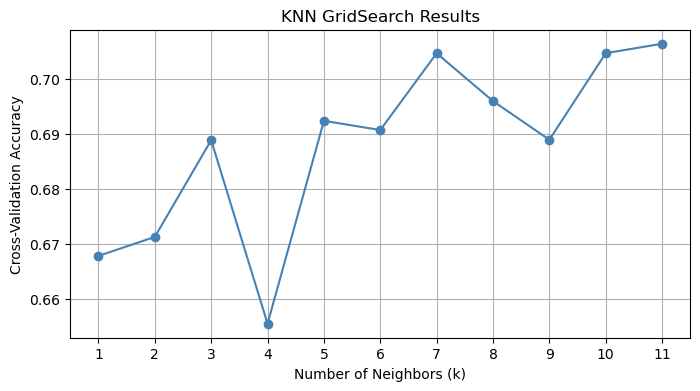

In [8]:
results = knn_grid.cv_results_
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 12), results['mean_test_score'], marker='o', color='steelblue')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN GridSearch Results')
plt.xticks(np.arange(1, 12))
plt.grid(True)
plt.show()

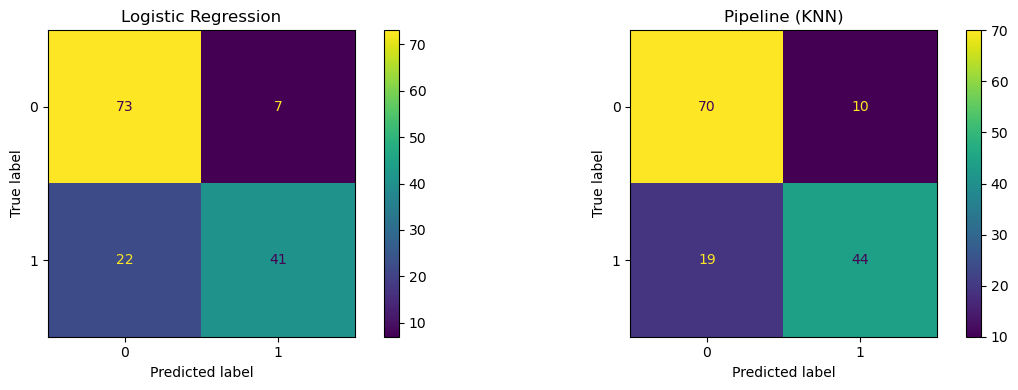

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pipeline, ax=axes[1])
axes[1].set_title('Pipeline (KNN)')
plt.tight_layout()
plt.show()